# Recommender Systems, from Scratch: Retrieval + Ranking

This is a small series of notebooks that build up a **two-stage** recommender system —
the architecture most real-world systems (YouTube, Netflix, Spotify, ...) actually use:

1. **Retrieval** (a.k.a. candidate generation) — cheaply narrow millions of items down to a
   few hundred plausible candidates for a user. Needs to be fast; doesn't need to be
   perfectly ordered.
2. **Ranking** — take those candidates and carefully re-order them with a richer, more
   expensive model. This is affordable *only* because the candidate set is now small.

| Notebook | Stage | Method |
|---|---|---|
| `00_data_and_evaluation` | — | shared dataset + evaluation protocol (this one) |
| `01_retrieval_als` | Retrieval | Matrix factorization (implicit ALS) |
| `02_retrieval_embedding_similarity` | Retrieval | Item2Vec-style embeddings + vector similarity |
| `03_ranking_gbdt` | Ranking | Gradient-boosted trees (LightGBM, LambdaRank) |
| `04_retrieval_two_tower` | Retrieval | Two-Tower neural network |
| `05_comparison` | — | side-by-side comparison of every method above |

Every notebook trains and evaluates on **the exact same data and metrics** (defined once
in `rec_utils.py`), so the numbers you'll see across notebooks are genuinely comparable.

## 1. The problem setup

We're building a recommender for **implicit feedback**: we only observe *positive*
signals (a user watched/clicked/bought an item). We never observe explicit ratings, and
"the user didn't interact with item X" could mean "dislikes X" or just "never saw X" —
we can't tell which. This is the realistic case for almost every online product, and it's
harder than the classic "predict the star rating" (explicit feedback) setup.

The task we evaluate on: **given a user's history, predict the next item they'll
interact with.** This is exactly what a "Recommended for you" rail needs to do.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rec_utils as ru # auto created library with utility functions for this notebook

ru.setup_plot_style()
np.set_printoptions(precision=3, suppress=True)

interactions, user_prefs, item_genres, item_pop = ru.generate_synthetic_data()
# interaction, `t` is the position of the interaction in that user's history (0 = oldest)
interactions.head()

,user_id,item_id,t
0,0,107,0
1,0,325,1
2,0,212,2
3,0,193,3
4,0,209,4


In [2]:
user_prefs.shape, item_genres.shape, item_pop.shape

((600, 8), (400, 8), (400,))

## 2. Why synthetic data?

Real recommender datasets (MovieLens, etc.) are great, but they're a black box: you never
know the *true* user taste, so you can't fully sanity-check whether a model "understood"
anything or just memorized popularity. Here we generate a small synthetic dataset where:

- Every **user** has a hidden taste vector over 8 genres (`user_prefs`).
- Every **item** has a hidden genre vector (`item_genres`) plus a popularity bias
  (`item_pop`) — a few blockbusters, a long tail of niche items.
- Interactions are sampled with probability proportional to `taste · genre + popularity +
  noise`.

No model in these notebooks ever sees `user_prefs` or `item_genres` directly — they only
see the `(user_id, item_id)` interaction log, exactly like a real system. We keep the
ground truth around purely so *we*, the humans, can sanity-check what the models learn
(e.g. "did the item embeddings cluster by genre?").

In [3]:
n_users = interactions.user_id.nunique()
n_items = interactions.item_id.nunique()
n_inter = len(interactions)
sparsity = 1 - n_inter / (n_users * n_items)

print(f"{n_users} users, {n_items} items, {n_inter} interactions")
print(f"Matrix sparsity: {sparsity:.2%} of all possible user-item pairs are empty")
print(f"Avg interactions per user: {n_inter / n_users:.1f}")

600 users, 400 items, 15000 interactions
Matrix sparsity: 93.75% of all possible user-item pairs are empty
Avg interactions per user: 25.0


This sparsity level (~94% empty) is what makes recommendation hard, and typical: most
users have only interacted with a tiny fraction of the catalog.

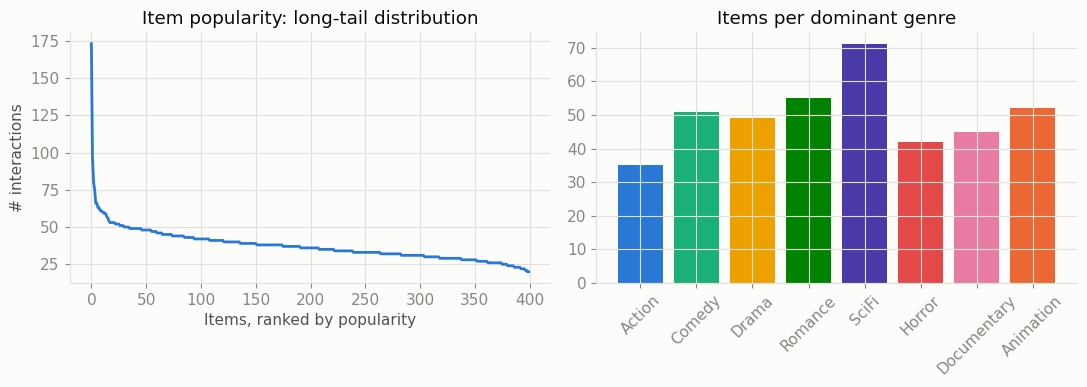

In [4]:
item_counts = interactions["item_id"].value_counts().sort_values(ascending=False).values
dominant_genre = item_genres.argmax(axis=1)
genre_counts = pd.Series(dominant_genre).value_counts().reindex(range(ru.N_GENRES), fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(item_counts, color=ru.SEQUENTIAL_BLUE[3], linewidth=2)
axes[0].set_title("Item popularity: long-tail distribution")
axes[0].set_xlabel("Items, ranked by popularity")
axes[0].set_ylabel("# interactions")

axes[1].bar(ru.GENRE_NAMES, genre_counts.values, color=ru.GENRE_COLORS)
axes[1].set_title("Items per dominant genre")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

A classic power-law popularity curve (left) — this is exactly why a naive "just show the
most popular items" baseline is dangerously decent, and why we need to check every method
against it. The genre distribution (right) is roughly balanced by construction.

## 3. Train / test split: leave-one-out

You cannot randomly split interaction *rows* into train/test the way you would for a
generic ML dataset — that leaks the future into training (a user's item #3 could end up
in train while their item #1 ends up in test) and inflates every metric.

Instead we use **leave-one-out**: each user's *most recent* interaction (this is the last interaction) goes to the test
set, everything earlier goes to train. The task becomes "given everything up to now,
predict what's next" — realistic, and leak-free.

In [5]:
train, test = ru.leave_one_out_split(interactions)
print(f"train: {len(train)} rows   test: {len(test)} rows (exactly 1 per user)")
train.head()

train: 14400 rows   test: 600 rows (exactly 1 per user)


,user_id,item_id,t
0,0,107,0
1,0,325,1
2,0,212,2
3,0,193,3
4,0,209,4


## 4. Evaluation metrics: Recall@K and NDCG@K

For each test user we ask a model for its top-K recommendations (excluding anything the
user already interacted with in train), and check whether the true held-out item shows
up. Here are the general definitions used across the recsys literature — we'll simplify
them for our specific setup right after.

**Precision@K** — of the K items shown, what fraction were actually relevant?

$$\text{Precision@K} = \frac{|\{\text{relevant items}\} \cap \{\text{top-}K\text{ recommended}\}|}{K}$$

**Recall@K** — of *all* the relevant items that exist, what fraction did we manage to surface in the top K?

$$\text{Recall@K} = \frac{|\{\text{relevant items}\} \cap \{\text{top-}K\text{ recommended}\}|}{|\{\text{relevant items}\}|}$$

**DCG@K / NDCG@K** — rewards relevant items more the higher they're ranked, and (unlike Precision/Recall) can natively handle *several* relevant items with *graded* relevance, not just a single yes/no hit:

$$\text{DCG@K} = \sum_{p=1}^{K} \frac{\text{rel}_p}{\log_2(p + 1)}$$

where $p$ is the 1-indexed position in the ranked list and $\text{rel}_p$ is the relevance of the item shown at position $p$ (1 if relevant, 0 if not, in the binary case). This is normalized by the best possible ordering's DCG — the "ideal DCG" (IDCG@K), i.e. what you'd get if every relevant item were ranked first:

$$\text{NDCG@K} = \frac{\text{DCG@K}}{\text{IDCG@K}}$$

**MRR (Mean Reciprocal Rank)** — averaged, across users, reciprocal position of the *first* relevant item found:

$$\text{MRR} = \frac{1}{|U|}\sum_{u \in U} \frac{1}{\text{rank}_u}$$

where $\text{rank}_u$ is the (1-indexed) position of the first relevant item for user $u$ (0 if nothing relevant appears within the cutoff, when truncated to MRR@K).

### Simplifying these formulas for our leave-one-out setup

Every test user here has **exactly one** relevant item — the single item we held out.
That collapses all four formulas above into much simpler expressions:

- **Recall@K**: $|\{\text{relevant items}\}| = 1$, so the denominator disappears —
  Recall@K becomes just the 0/1 "was it found" indicator.
- **Precision@K**: the numerator can only be 0 or 1, so
  $\text{Precision@K} = \text{Recall@K} / K$ — it carries no information Recall@K
  doesn't already have, just scaled down by a constant.
- **NDCG@K**: with only one relevant item, every term in the DCG sum is 0 *except* the
  one position where the true item lands (if it's within the top K at all) — the sum
  collapses to a single term. And the ideal ordering (IDCG@K) simply places that one
  relevant item first, at position $p = 1$, giving
  $\text{IDCG@K} = 1/\log_2(1+1) = 1/\log_2(2) = 1$. Dividing by 1 does nothing, so
  NDCG@K reduces to DCG@K itself:

  $$\text{NDCG@K} = \frac{1}{\log_2(\text{rank} + 2)} \quad \text{if the true item is in the top K, else } 0$$

  (`rank` here is the 0-indexed position used in the code, so `rank + 1 = p`, matching
  the general formula above — this is exactly what `rec_utils.ndcg_at_k` computes.)
- **MRR**, restricted to a single relevant item and truncated at K, also reduces to a
  single reciprocal-rank term: $1/(\text{rank}+1)$ if found in the top K, else 0.

### Why Recall + NDCG here, and not Precision or MRR

**Not Precision@K**: since Precision@K = Recall@K / K in this setup, it adds no new
information — and it actively makes cross-K comparisons misleading. Recall@K is
monotonically non-decreasing in K (showing more candidates can only help), which matches
intuition. Precision@K instead *shrinks* as K grows for the exact same model (roughly
halving from Precision@10 to Precision@20), purely because of the bigger denominator —
that's a property of K, not of the model, so it's not a useful axis to report here.

**Not MRR**: MRR and NDCG@K would behave very similarly in this specific single-relevant
-item case — both are gated by "was it found at all" and both decay with rank. The
difference is the *shape* of that decay: MRR's $1/(\text{rank}+1)$ falls off harmonically
(rank 1 → 2 already halves the score), while NDCG's $1/\log_2(\text{rank}+2)$ falls off
logarithmically — a gentler, more gradual penalty, generally considered a better model of
how a user's attention actually decays down a list. NDCG is also the more general tool:
if a dataset had multiple relevant items or graded relevance (e.g. "clicked" vs.
"purchased"), NDCG handles that natively by summing contributions from every relevant
item, while MRR would still only look at the first one. We use NDCG throughout this
series so the metric doesn't have to change if the setup gets richer later.

In [6]:
# A toy example to build intuition before we run this on real models.
ranked = [42, 7, 99, 3, 15]   # a model's top-5 recommendations, best first
true_item = 99

print("Recall@5:", ru.recall_at_k(ranked, true_item, 5))   # found within top 5 -> 1.0
print("Recall@2:", ru.recall_at_k(ranked, true_item, 2))   # not in top 2      -> 0.0
print("NDCG@5:  ", round(ru.ndcg_at_k(ranked, true_item, 5), 3))  # found, but at rank 2

true_item_2 = 42
print("NDCG@5 if it had been ranked #1:", round(ru.ndcg_at_k(ranked, true_item_2, 5), 3))

Recall@5: 1.0
Recall@2: 0.0
NDCG@5:   0.5
NDCG@5 if it had been ranked #1: 1.0


## 5. The baseline every method must beat: popularity

The simplest possible recommender: ignore the user entirely, always recommend whatever is
globally most popular (that they haven't already seen). If a fancy personalized model
can't beat this, it isn't learning anything useful about individual taste.

In [7]:
seen = ru.user_seen_items(train) # train.groupby("user_id")["item_id"].apply(set).to_dict(), movies already seen by the user
item_counts_train = train["item_id"].value_counts()
item_counts_train.sort_index(ascending=True, inplace=True)
pop_scores = item_counts_train.values

In [8]:
ru.rank_topn(pop_scores, seen.get(0, set()), 3) # user 0, top-3 recommendations based on popularity
# seen.get(0, set()) returns the set of items that user 0 has already seen, so we don't recommend those.

[342, 305, 238]

In [9]:
def recommend_popularity(user_id, n):
    return ru.rank_topn(pop_scores, seen.get(user_id, set()), n)

metrics = ru.evaluate_recommender(recommend_popularity, train, test, k_list=(10, 20))
ru.save_results("00_popularity", metrics)
metrics 
# These are the metrics for the popularity-based recommender, which is a simple baseline. 
# We will compare more sophisticated models against this baseline.

Saved results to D:\Pablo_Data\Documentos\VSCode\revolut\recommendation_algorithms\results\00_popularity.json


{'recall@10': 0.051666666666666666,
 'ndcg@10': 0.029233564060177623,
 'recall@20': 0.085,
 'ndcg@20': 0.03777413559395742}

## 6. What's next

Keep these popularity numbers in mind — every retrieval method in the next notebooks
(`01_retrieval_als`, `02_retrieval_embedding_similarity`, `04_retrieval_two_tower`) is
trying to beat them by actually learning what each user likes. Notebook `03_ranking_gbdt`
then shows how to squeeze out extra precision by re-ranking a retrieval model's
candidates. `05_comparison` pulls every result together at the end.